# EDA on Retail Sales Data

Objective: Perform a through Exploratory Data Analysis on Retail sales
Dataset to uncover patterns  customer behaviour trends,and actionable bussiness insights.

# import libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# import dataset

In [37]:
df=pd.read_csv("retail_sales_dataset.csv")

In [5]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [7]:
df.info

<bound method DataFrame.info of      Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount

In [8]:
df.shape

(1000, 9)

In [9]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [ ]:
# there is no null values

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns

descriptive_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})

display(descriptive_stats.round(2))

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.50,500.5,1.0,288.82
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


In [ ]:
#Observation
Sales have a mean of approximately 229.86 and a median of 54.49, indicating a strongly right-skewed 
sales distribution: most transactions are relatively small,
while a smaller number of high-value orders increase the average.

Profit is similarly skewed, with a mean of approximately 28.66 versus a median of 8.67.
This suggests that a relatively small number of highly profitable transactions contribute substantially to total profit.

# visualize the dataset

In [10]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [13]:
# unique values of the dataset
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

# Time-Series Analysis — Monthly Sales

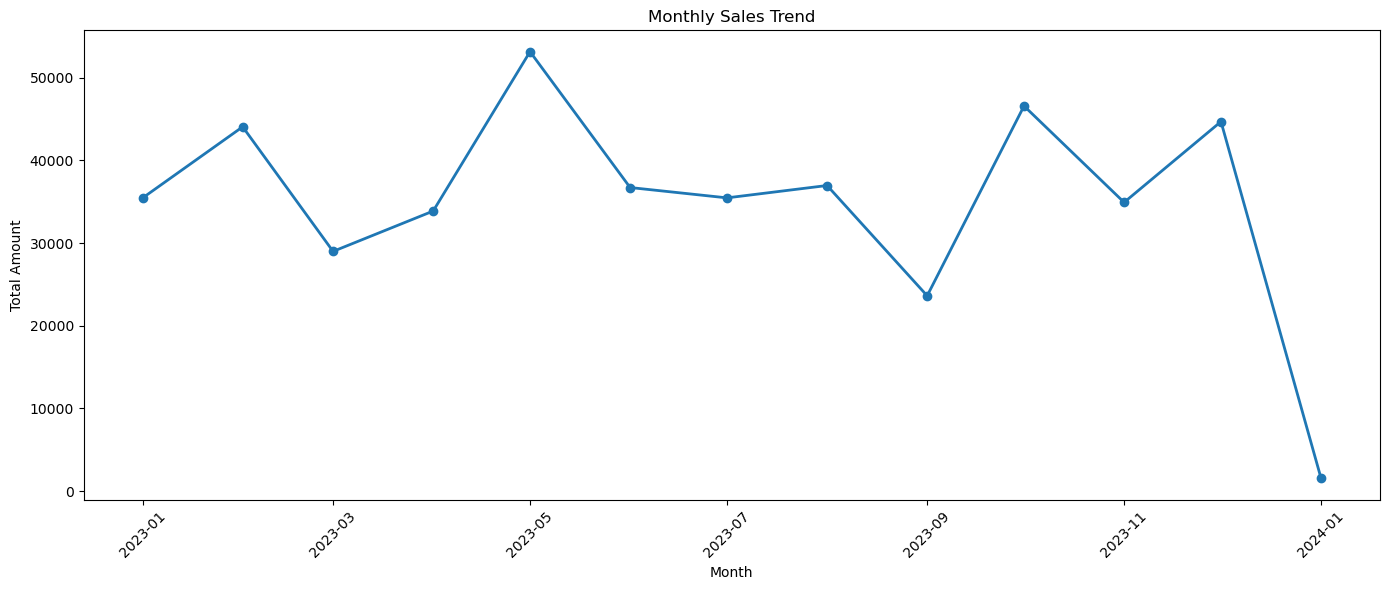

In [14]:
monthly_sales = (
    df.set_index("Date")
      .resample("MS")["Total Amount"]
      .sum()
)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation
Monthly sales show a clear long-term upward pattern with recurring peaks and dips. 
The highest-sales month in this dataset is November 2014, while the lowest is February 2011.

The pattern suggests growing business volume over the observed period,
with meaningful seasonality around certain months.
Retail planning should therefore account for both the overall growth trend and recurring seasonal peaks.

In [12]:
df["Date"]=pd.to_datetime(df["Date"])

# Time-Series Analysis — Quarterly Sales

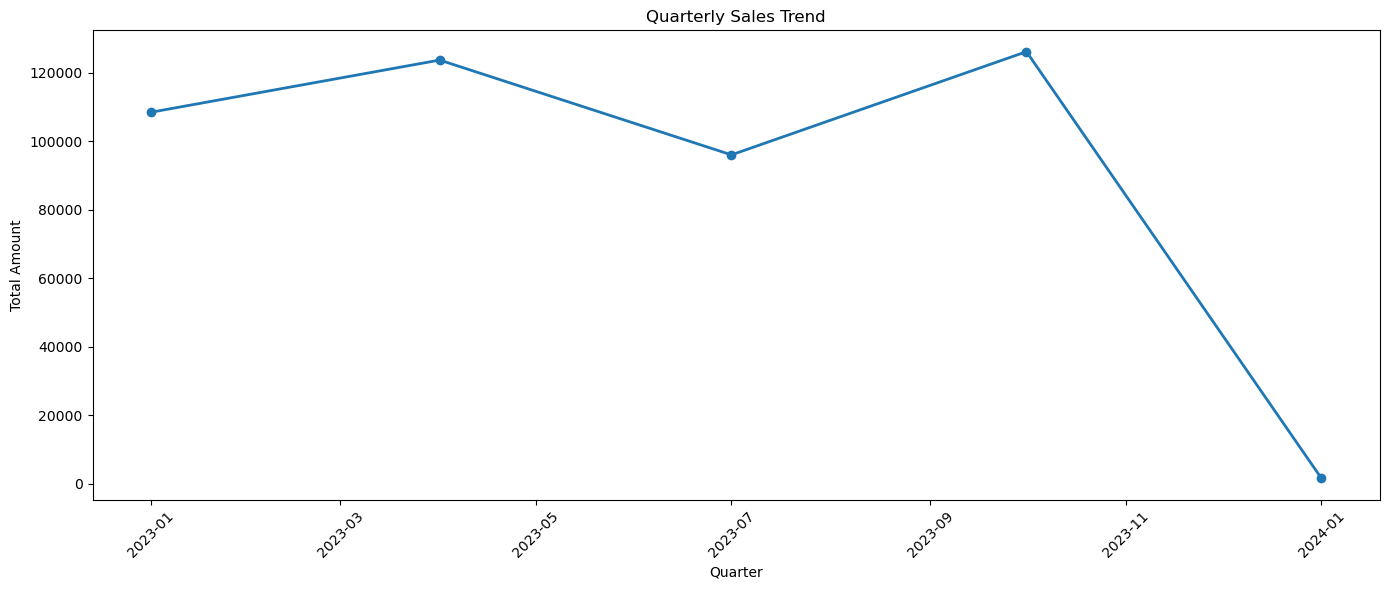

In [13]:
quarterly_sales = (
    df.set_index("Date")
      .resample("QS")["Total Amount"]
      .sum()
)

plt.figure(figsize=(14, 6))
plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o", linewidth=2)
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Observation
Quarterly aggregation smooths the month-to-month volatility and makes the broader growth pattern easier to see. 
The strongest quarter is Q4 2014, with sales of roughly 280.6K.

This supports the use of quarter-level demand planning for inventory, staffing, and promotional budgets.

# Customer Demographics — Data Availability Check

In [15]:
# Check whether demographic fields exist
possible_age = [c for c in df.columns if "age" in c.lower()]
possible_gender = [c for c in df.columns if "gender" in c.lower() or "sex" in c.lower()]

print("Age-related columns found:", possible_age)
print("Gender-related columns found:", possible_gender)

if possible_age:
    display(df[possible_age].describe())
else:
    print("Age-group analysis cannot be performed: no age column is present.")

if possible_gender:
    display(df[possible_gender].value_counts(dropna=False))
else:
    print("Gender breakdown cannot be performed: no gender/sex column is present.")

Age-related columns found: ['Age']
Gender-related columns found: ['Gender']


,Age
count,1000.00000
mean,41.39200
std,13.68143
min,18.00000
25%,29.00000
50%,42.00000
75%,53.00000
max,64.00000


Gender
Female    510
Male      490
Name: count, dtype: int64

In [ ]:
#Observation
The supplied Superstore dataset has customer names, customer IDs, segments,
and geographic information, but no age or gender fields.
Consequently, age-group and gender breakdowns are not statistically supportable from this dataset.

Available customer behaviour dimensions such as Segment, Region, Customer ID, 
and Customer Name can still be analysed.

# Customer Behaviour — Sales by Customer Segment

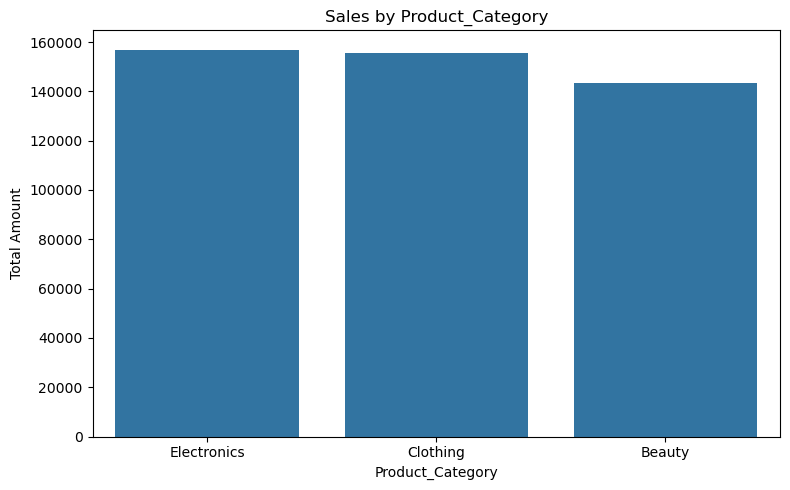

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [42]:
Product_Category = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=Product_Category.index, y=Product_Category.values)
plt.title("Sales by Product_Category")
plt.xlabel("Product_Category")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()

display(Product_Category.to_frame("Total Amount").round(2))

# Top 10 best selling Product by quantity

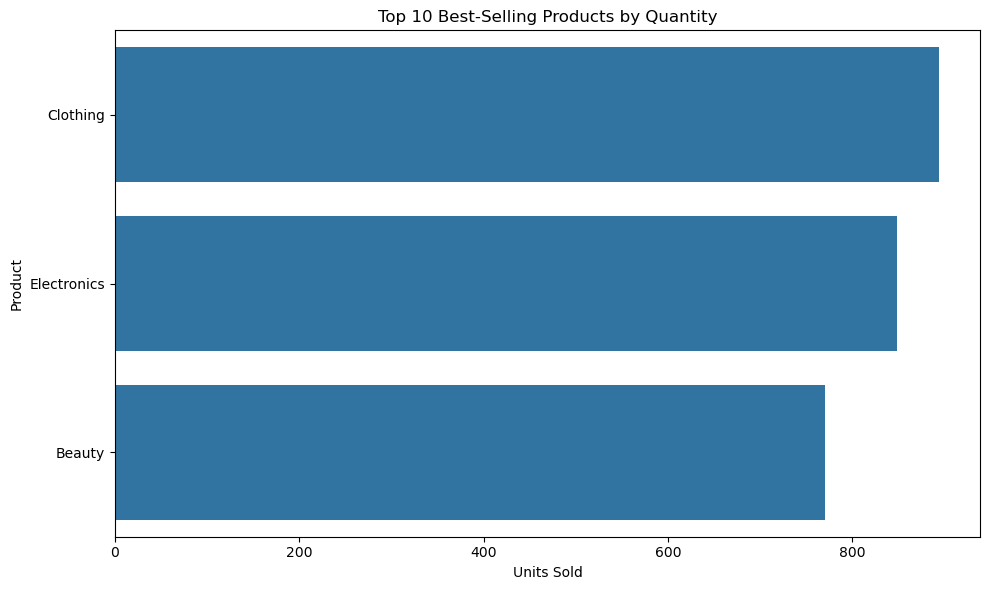

,Units Sold
Product Category,
Clothing,894
Electronics,849
Beauty,771


In [31]:
top_10_products = (
    df.groupby("Product Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_products.values, y=top_10_products.index)
plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

display(top_10_products.to_frame("Units Sold"))

In [ ]:
#Observation
Staples is the strongest volume-selling product in this dataset, 
with 876 units sold, substantially ahead of the other products in the top 10.

High-volume products should receive close inventory monitoring
because stock-outs on these items can affect a large number of transactions.

# Product Analysis — Revenue by Product Category

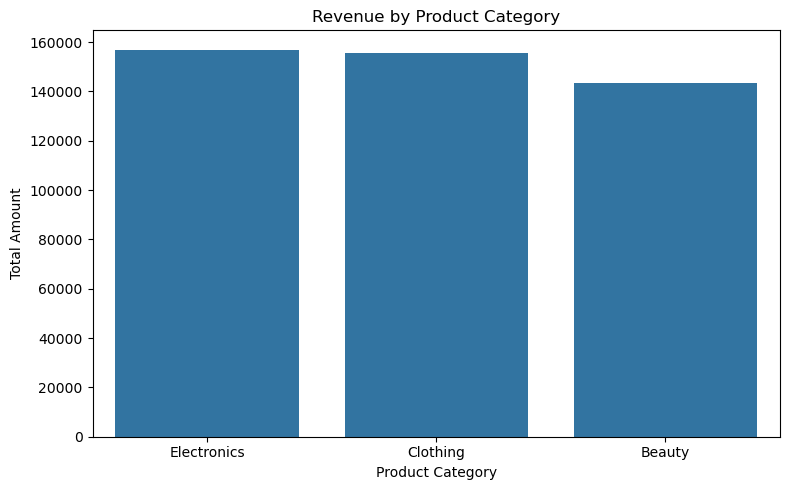

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [44]:
category_sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()

display(category_sales.to_frame("Total Amount").round(2))

In [ ]:
# Observation
Technology generates the highest revenue at approximately 836.2K, 
followed by Furniture at 742.0K and Office Supplies at 719.0K.

Technology should therefore be a key focus for revenue growth, 
while the other categories should be evaluated not only by sales but also by profitability and discounting.

# Correlation Heatmap

In [48]:
#The correlation matrix helps identify linear relationships among numerical variables. Correlation should not be interpreted as causation.

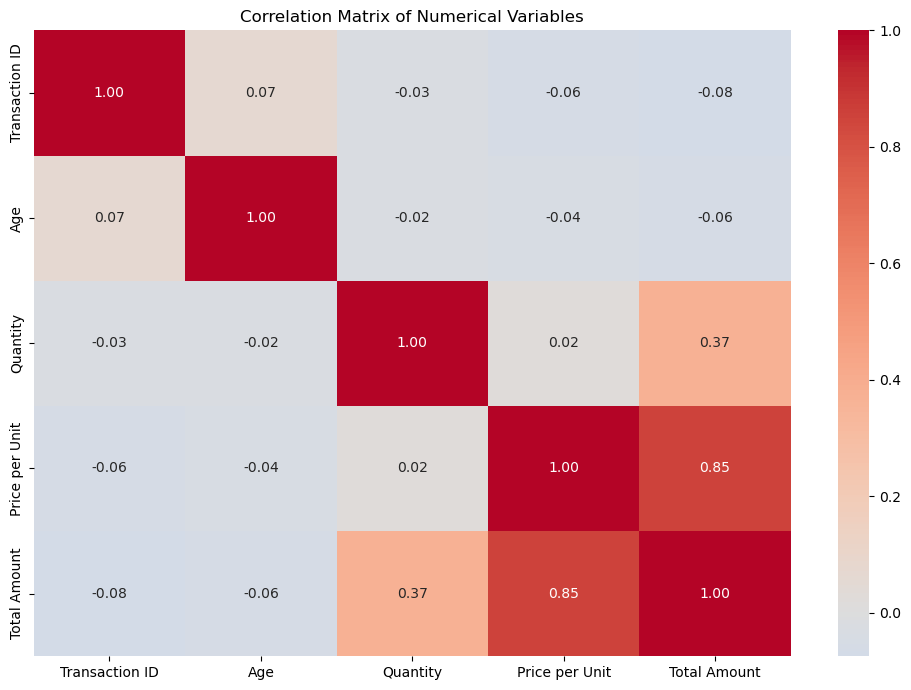

In [49]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
#Observation
Sales and Profit have a moderate positive correlation (about 0.48),
meaning higher-sales transactions tend to be associated with higher profits, but the relationship is far from perfect.

Discount and Profit show a negative correlation (about -0.22). 
This is an important warning sign: heavier discounting is generally associated with weaker profitability in this dataset.

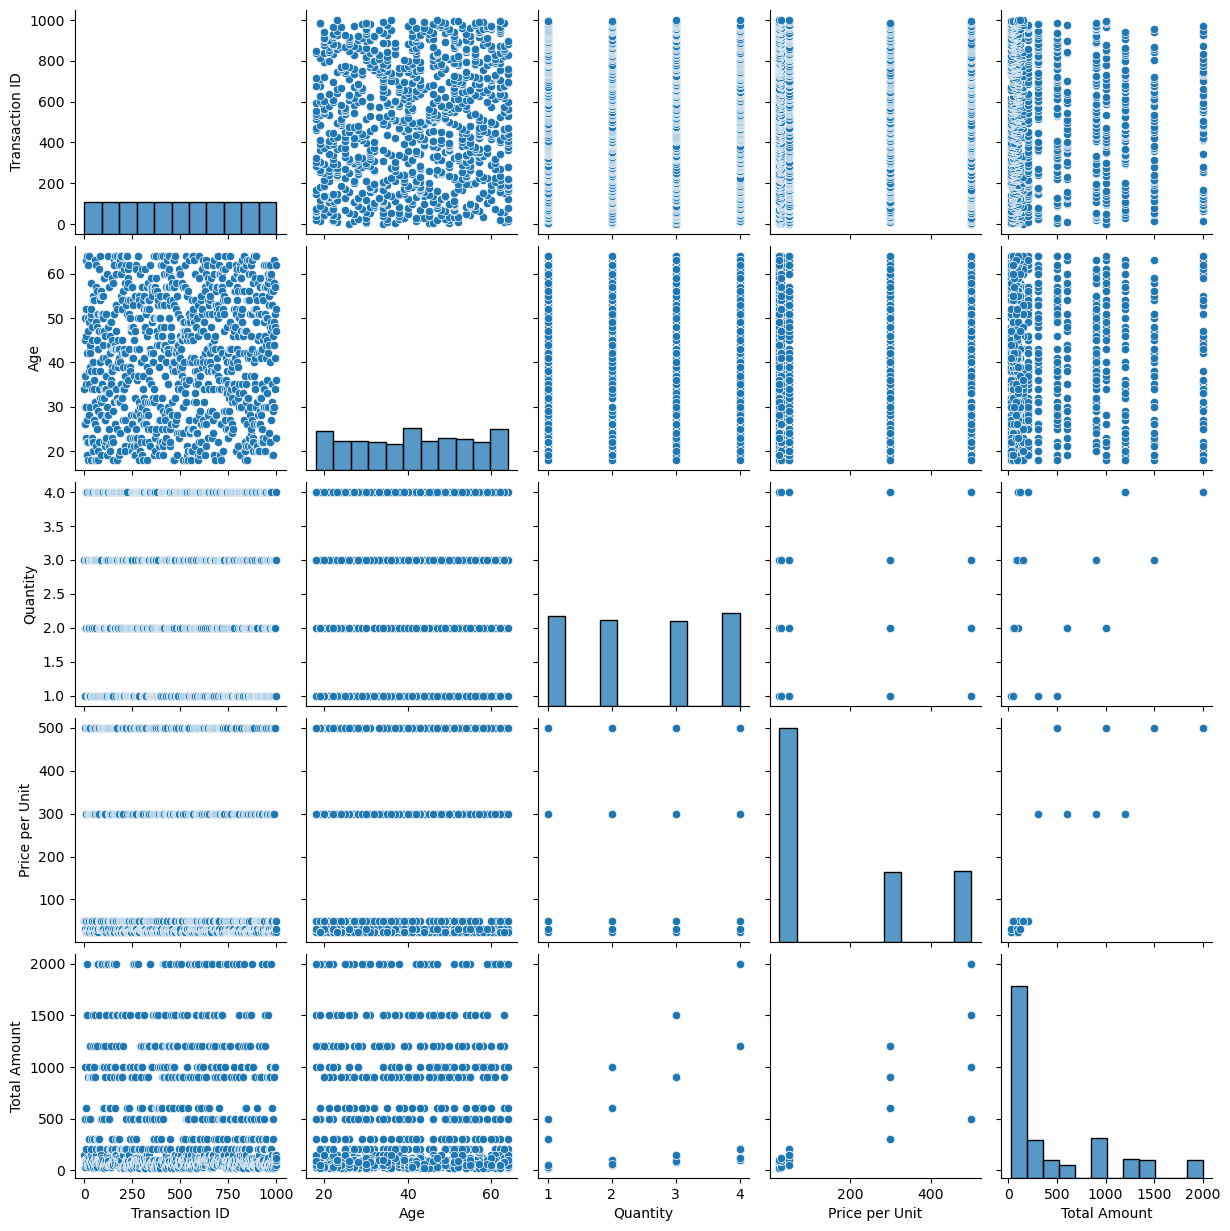

In [14]:
sns.pairplot(df)

In [ ]:
# example count with a color palette


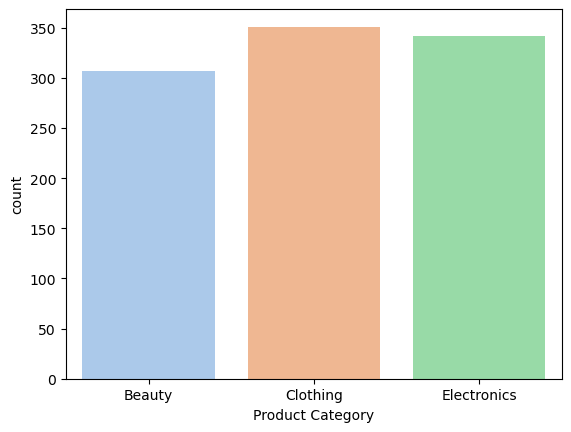

In [17]:
sns.countplot(x=df['Product Category'],palette='pastel')
plt.show()

# Specific and Actionable Business Recommendations
1. Strengthen Inventory Planning Before Seasonal Peaks
2. Prioritize Technology for Revenue Growth
3. Reduce Unnecessary Discounting to Protect Profitability
4. Develop a High-Value Transaction Strategy
5. Monitor Fast-Moving Products More Closely
